In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

In [2]:
# Load the MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize the pixel values to [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Flatten the images for the autoencoder
X_train_flat = X_train.reshape(-1, 28 * 28)
X_test_flat = X_test.reshape(-1, 28 * 28)

# One-hot encode the labels for classification
y_train_onehot = tf.keras.utils.to_categorical(y_train, 10)
y_test_onehot = tf.keras.utils.to_categorical(y_test, 10)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
# Define the input shape
input_dim = 28 * 28
encoding_dim = 64  # Dimension of the encoded representation

# Encoder
input_img = Input(shape=(input_dim,))
encoded = Dense(128, activation='relu')(input_img)
encoded = Dense(encoding_dim, activation='relu')(encoded)

# Decoder
decoded = Dense(128, activation='relu')(encoded)
decoded = Dense(input_dim, activation='sigmoid')(decoded)

# Autoencoder model
autoencoder = Model(input_img, decoded)

# Compile the autoencoder
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

In [4]:
# Train the autoencoder
autoencoder.fit(
    X_train_flat, X_train_flat,
    epochs=10,
    batch_size=256,
    shuffle=True,
    validation_data=(X_test_flat, X_test_flat)
)

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.3225 - val_loss: 0.1367
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.1293 - val_loss: 0.1090
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.1072 - val_loss: 0.0982
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0984 - val_loss: 0.0937
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0938 - val_loss: 0.0900
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0906 - val_loss: 0.0878
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - loss: 0.0882 - val_loss: 0.0856
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0863 - val_loss: 0.0845
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.0851 - val_loss: 0.0830
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.0838 - val_loss: 0.0819


In [5]:
# Extract the encoder model
encoder = Model(input_img, encoded)

# Generate encoded features
X_train_encoded = encoder.predict(X_train_flat)
X_test_encoded = encoder.predict(X_test_flat)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [6]:
# Define the classifier
classifier_input = Input(shape=(encoding_dim,))
classifier_output = Dense(64, activation='relu')(classifier_input)
classifier_output = Dense(10, activation='softmax')(classifier_output)

# Classifier model
classifier = Model(classifier_input, classifier_output)

# Compile the classifier
classifier.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [7]:
# Train the classifier on encoded features
classifier.fit(
    X_train_encoded, y_train_onehot,
    epochs=10,
    batch_size=256,
    validation_data=(X_test_encoded, y_test_onehot)
)

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3415 - loss: 2.5308 - val_accuracy: 0.8161 - val_loss: 0.6356
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8308 - loss: 0.5769 - val_accuracy: 0.8855 - val_loss: 0.4055
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8814 - loss: 0.4090 - val_accuracy: 0.9016 - val_loss: 0.3407
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8987 - loss: 0.3462 - val_accuracy: 0.9094 - val_loss: 0.3138
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9060 - loss: 0.3184 - val_accuracy: 0.9134 - val_loss: 0.2972
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9146 - loss: 0.2948 - val_accuracy: 0.9170 - val_loss: 0.2793
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9176 - loss: 0.2788 - val_accuracy: 0.9253 - val_loss: 0.2560
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9222 - loss: 0.2657 - val_accuracy: 0.

In [8]:
# Evaluate the classifier on test data
loss, accuracy = classifier.evaluate(X_test_encoded, y_test_onehot, verbose=0)
print(f"Classifier Test Accuracy: {accuracy:.4f}")

Classifier Test Accuracy: 0.9330


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


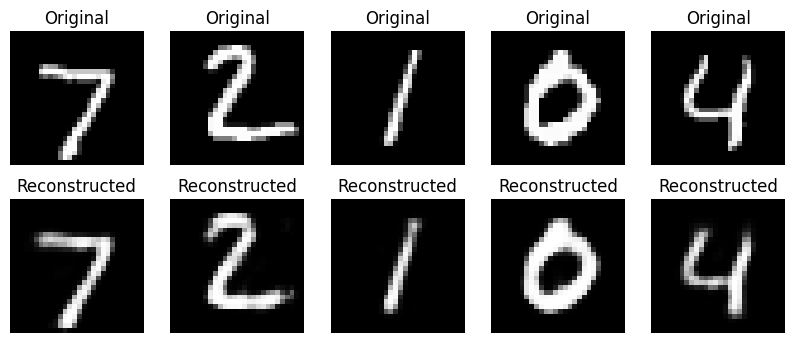

In [9]:
# Visualize some original and reconstructed images
decoded_imgs = autoencoder.predict(X_test_flat)

n = 5  # Number of images to display
plt.figure(figsize=(10, 4))
for i in range(n):
    # Original
    plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstructed
    plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')
plt.show()